In [1]:
import os
import torch
from PIL import Image
import numpy as np
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Model Description

For this homework we will use Convolutional Neural Network (CNN). We'll use PyTorch.

We need to develop the model with following structure:

- The shape for input should be `(3, 200, 200)` (channels first format in PyTorch)
- Next, create a convolutional layer (`nn.Conv2d`):
     - Use 32 filters (output channels)
     - Kernel size should be `(3, 3)` (that's the size of the filter), padding = 0, stride = 1
     - Use `'relu'` as activation
- Reduce the size of the feature map with max pooling (`nn.MaxPool2d`)
     - Set the pooling size to `(2, 2)`
- Turn the multi-dimensional result into vectors using `flatten` or `view`
- Next, add a `nn.Linear` layer with 64 neurons and `'relu'` activation
- Finally, create the `nn.Linear` layer with 1 neuron - this will be the output
     - The output layer should have an activation - use the appropriate activation for the binary classification case
- As optimizer use `torch.optim.SGD` with the following parameters:

`torch.optim.SGD(model.parameters(), lr=0.002, momentum=0.8)`

In [2]:
image_size = 200

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


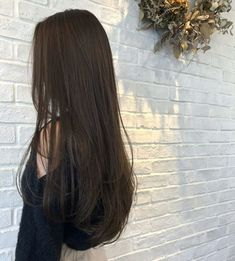

In [4]:
img = Image.open("data/train/straight/0f9d3172f6ec3206d6f76318830159b2.jpg")
img

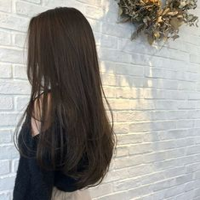

In [5]:
img.resize((image_size,image_size))

In [6]:
X = np.array(img.resize((image_size,image_size)))
X

array([[[238, 236, 224],
        [238, 236, 224],
        [237, 235, 223],
        ...,
        [179, 176, 169],
        [213, 211, 206],
        [206, 203, 197]],

       [[228, 226, 215],
        [232, 229, 219],
        [235, 233, 222],
        ...,
        [184, 180, 173],
        [213, 210, 205],
        [209, 206, 200]],

       [[227, 224, 215],
        [231, 227, 219],
        [234, 231, 222],
        ...,
        [208, 204, 196],
        [207, 204, 197],
        [210, 207, 200]],

       ...,

       [[194, 212, 224],
        [195, 213, 225],
        [197, 215, 226],
        ...,
        [188, 191, 198],
        [178, 181, 188],
        [176, 179, 186]],

       [[200, 218, 230],
        [194, 212, 224],
        [199, 217, 229],
        ...,
        [176, 179, 186],
        [169, 172, 179],
        [168, 171, 178]],

       [[200, 218, 230],
        [202, 220, 232],
        [202, 220, 232],
        ...,
        [170, 174, 180],
        [170, 174, 180],
        [169, 173, 179]]

In [7]:
X.shape

(200, 200, 3)

In [8]:
class HairtypeDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i,cls in enumerate(self.classes)}

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    
    def __len__(self):
        return len(self.image_paths)

    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])

test_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
train_dataset = HairtypeDataset(
    data_dir='./data/train',
    transform=train_transforms
)

test_dataset = HairtypeDataset(
    data_dir='./data/test',
    transform=test_transforms
)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)

In [12]:
classes = list(train_dataset.class_to_idx)
classes

['curly', 'straight']

## Question 1

Which loss function you will use?

- nn.MSELoss()
- nn.BCEWithLogitsLoss()
- nn.CrossEntropyLoss()
- nn.CosineEmbeddingLoss()

In [13]:
# nn.BCEWithLogitsLoss()

## Question 2
What's the total number of parameters of the model? You can use torchsummary or count manually.

- 896
- 11214912
- 15896912
- 20073473

In [14]:
class HairtypeClassifierNN(nn.Module):
    def __init__(self):
        super(HairtypeClassifierNN, self).__init__()

        # add custom layers
        self.conv_layer = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=0,
            stride=1
        )
        self.relu = nn.ReLU()
        self.max_pooling = nn.MaxPool2d(2)
        self.output_layer = nn.Linear(32*99*99, 64)
        self.linear1 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.relu(x)
        x = self.max_pooling(x)
        x = torch.flatten(x, 1)
        x = self.output_layer(x)
        x = self.relu(x)
        x = self.linear1(x)
        x = self.sigmoid(x)
        return x

In [15]:
model= HairtypeClassifierNN()
model.to(device)

HairtypeClassifierNN(
  (conv_layer): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (max_pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (output_layer): Linear(in_features=313632, out_features=64, bias=True)
  (linear1): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [16]:
optimizer = optim.SGD(model.parameters(), lr=0.002, momentum=0.8)
criterion = nn.BCEWithLogitsLoss()

In [17]:
from torchsummary import summary
summary(model, input_size=(3, 200, 200))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 198, 198]             896
              ReLU-2         [-1, 32, 198, 198]               0
         MaxPool2d-3           [-1, 32, 99, 99]               0
            Linear-4                   [-1, 64]      20,072,512
              ReLU-5                   [-1, 64]               0
            Linear-6                    [-1, 1]              65
           Sigmoid-7                    [-1, 1]               0
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.46
Forward/backward pass size (MB): 21.54
Params size (MB): 76.57
Estimated Total Size (MB): 98.57
----------------------------------------------------------------


In [18]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 20073473


In [19]:
# 20073473

## Question 3

What is the median of training accuracy for all the epochs for this model?

- 0.05
- 0.12
- 0.40
- 0.84

In [20]:
num_epochs = 10
history = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(test_dataset)
    val_epoch_acc = correct_val / total_val
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6825, Acc: 0.4869, Val Loss: 0.6711, Val Acc: 0.4876
Epoch 2/10, Loss: 0.6535, Acc: 0.4869, Val Loss: 0.6605, Val Acc: 0.4876
Epoch 3/10, Loss: 0.6409, Acc: 0.4869, Val Loss: 0.6580, Val Acc: 0.4876
Epoch 4/10, Loss: 0.6472, Acc: 0.4856, Val Loss: 0.6622, Val Acc: 0.4876
Epoch 5/10, Loss: 0.6422, Acc: 0.4869, Val Loss: 0.6525, Val Acc: 0.4925
Epoch 6/10, Loss: 0.6277, Acc: 0.4894, Val Loss: 0.6550, Val Acc: 0.4876
Epoch 7/10, Loss: 0.6187, Acc: 0.4869, Val Loss: 0.6557, Val Acc: 0.4876
Epoch 8/10, Loss: 0.6130, Acc: 0.4869, Val Loss: 0.6521, Val Acc: 0.4876
Epoch 9/10, Loss: 0.6070, Acc: 0.4881, Val Loss: 0.6549, Val Acc: 0.4876
Epoch 10/10, Loss: 0.6019, Acc: 0.4869, Val Loss: 0.6561, Val Acc: 0.4876


In [21]:
np.median(history['acc'])

np.float64(0.4868913857677903)

In [22]:
# 0.487
# 0.40

## Question 4

What is the standard deviation of training loss for all the epochs for this model?

- 0.007
- 0.078
- 0.171
- 1.710

In [23]:
np.std(history['loss'])

np.float64(0.02343182713522859)

In [24]:
# 0.022
# 0.007

## Question 5

Let's train our model for 10 more epochs using the same code as previously.

Note: make sure you don't re-create the model. we want to continue training the model we already started training.

What is the mean of test loss for all the epochs for the model trained with augmentations?

- 0.008
- 0.08
- 0.88
- 8.88

In [25]:
train_transforms = transforms.Compose([
    transforms.RandomRotation(50),
    transforms.RandomResizedCrop(image_size, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])

train_dataset = HairtypeDataset(
    data_dir='./data/train',
    transform=train_transforms
)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)

In [26]:
num_epochs = 10
history = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(test_dataset)
    val_epoch_acc = correct_val / total_val
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6474, Acc: 0.4919, Val Loss: 0.6538, Val Acc: 0.4975
Epoch 2/10, Loss: 0.6538, Acc: 0.5044, Val Loss: 0.6571, Val Acc: 0.5821
Epoch 3/10, Loss: 0.6569, Acc: 0.5468, Val Loss: 0.6513, Val Acc: 0.5373
Epoch 4/10, Loss: 0.6413, Acc: 0.5431, Val Loss: 0.6662, Val Acc: 0.6517
Epoch 5/10, Loss: 0.6805, Acc: 0.6792, Val Loss: 0.6524, Val Acc: 0.6418
Epoch 6/10, Loss: 0.6464, Acc: 0.5581, Val Loss: 0.6592, Val Acc: 0.6716
Epoch 7/10, Loss: 0.6461, Acc: 0.5793, Val Loss: 0.6466, Val Acc: 0.6169
Epoch 8/10, Loss: 0.6478, Acc: 0.5680, Val Loss: 0.6517, Val Acc: 0.6169
Epoch 9/10, Loss: 0.6446, Acc: 0.5581, Val Loss: 0.6514, Val Acc: 0.6269
Epoch 10/10, Loss: 0.6349, Acc: 0.5556, Val Loss: 0.6507, Val Acc: 0.5672


In [27]:
np.mean(history['val_loss'])

np.float64(0.6540352296028564)

In [28]:
# 0.65
## 0.88

## Question 6

What's the average of test accuracy for the last 5 epochs (from 6 to 10) for the model trained with augmentations?

- 0.08
- 0.28
- 0.68
- 0.98

In [29]:
history['val_acc'][5:]

[0.6716417910447762,
 0.6169154228855721,
 0.6169154228855721,
 0.6268656716417911,
 0.5671641791044776]

In [30]:
np.mean(history['val_acc'][5:])

np.float64(0.6199004975124378)

In [31]:
# 0.523
## 0.68